# Building a simulation of a 2D drone

## Setup
Create a conda environment using

`conda create -n 2ddrone pygame stable-baselines3 ipykernel jupyterlab matplotlib`

You can then open this jupyter notebook in jupyter lab or VS code.  In VS code, you should be able to choose the 2ddrone environment on the top right.

## Using a python class to simulate a simple ball in 2D
The ball should be subjected to gravity, therefore it is subject to a force towards negative `y` that is the same as its mass.

### Define a python class of the object to be simulated

In [1]:
import numpy as np

class Ball:
    def __init__(self, x, y, mass):
        
        # Object parameters (will not change)
        self.mass = mass # in [kg]

        # State variables (these will change during the life of the object)
        self.x = x # in [m]
        self.y = y
        self.vx = 0 # in [m/s]
        self.vy = 0

    def step(self, dt):
        ''' steps the simulation of this ball. dt is in seconds '''

        # Forces are represented in Newtons. 
        fx = 0
        fy = -9.81 * self.mass
        ax = fx / self.mass
        ay = fy / self.mass
        self.vx = self.vx + ax * dt
        self.vy = self.vy + ay * dt
        self.x = self.x + self.vx * dt
        self.y = self.y + self.vy * dt

### Use the python class defined above
How long does a ball fall in 1 second?
Note that we are simulating 100 timesteps of 0.01 seconds each.

In [2]:
b = Ball(0, 0, 1) # create a 1kg ball in (0,0)
dt = 0.01
t = 0
while t < 1:
    b.step(dt)
    t += dt
b.y

-4.954049999999997

### Exercise 1.1
How much does the ball fall in 5 seconds?

In [3]:
b = Ball(0, 0, 1) # create a 1kg ball in (0,0)
dt = 0.01
t = 0
while t < 5:
    b.step(dt)
    t += dt
b.y

-123.36173099999993

### Exercise 1.2
Try using a different simulation step `dt`, e.g. 0.1 s or 0.00001 s. Does the result change? Explain why.

From now on, let's use a `dt` of 0.01 s, which seems to be pretty fine

The results doesn't change because it's a quantization level which determines just the minimum simulated time not the step size

### Exercise 1.3
Define an initial velocity to the ball by modifying its constructor to
`def __init__(self, x, y, vx, vy, mass):`

Consider a ball that starts at x=0, y=1, with a velocity of 2 m/s pointing at an elevation of 60 degrees to the top right.

Answer the following questions:
- what is the initial value of `vx` and `vy`?
- what is the `x` and `y` coordinates of the ball after 1, 2 and 3 seconds?
- run a simulation for 3 seconds, and save five numpy arrays (or a pandas dataframes with 5 columns, reporting the state variables of the ball -- position and velocity -- and the timestep)
- use matplotlib to plot the `x` coordinate vs time, and the `y` coordinate vs time. The time should be on the `x` axis of the plot, and should be expressed in seconds.
- use matplotlib to plot the trajectory of the ball in the `xy` plane

In [4]:
import math

In [5]:
b = Ball(0, 0, 1) # create a 1kg ball in (0,0)
#print(b.vx) #it's 0 because the ball is still


dt = 0.01
t = 0


while t < 5:
    if math.isclose(t, 1):
        print(b.x, b.y)
    
    elif math.isclose(t, 2):
        print(b.x, b.y)

    elif math.isclose(t, 3):
        print(b.x, b.y)
        
    b.step(dt)
    t += dt



0.0 -4.954049999999997
0.0 -19.71810000000001
0.0 -44.292149999999936


In [6]:
b = Ball(0, 0, 1) # create a 1kg ball in (0,0)
dt = 0.01
dt = 3/5 #3 seconds over 5 time steps
t = 0
import pandas as pd
l = []
while t <= 3:
    l.append((b.x, b.y, b.vx, b.vy, t))
    b.step(dt)
    t += dt

df = pd.DataFrame(l, columns=['x','y','vx','vy','t'])

df



,x,y,vx,vy,t
0,0.0,0.0000,0.0,0.000,0.0
1,0.0,-3.5316,0.0,-5.886,0.6
2,0.0,-10.5948,0.0,-11.772,1.2
3,0.0,-21.1896,0.0,-17.658,1.8
4,0.0,-35.3160,0.0,-23.544,2.4
5,0.0,-52.9740,0.0,-29.430,3.0


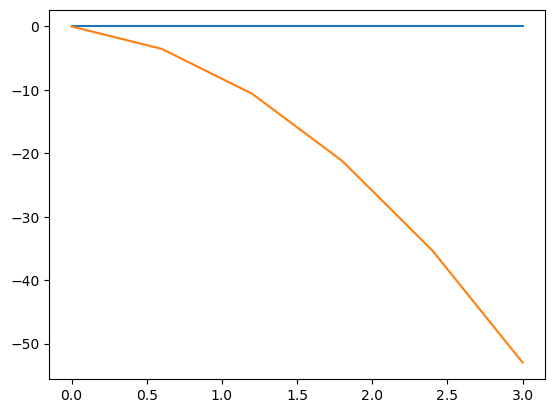

In [7]:
import matplotlib.pyplot as plt

plt.plot(df.t, df.x)
plt.plot(df.t, df.y)

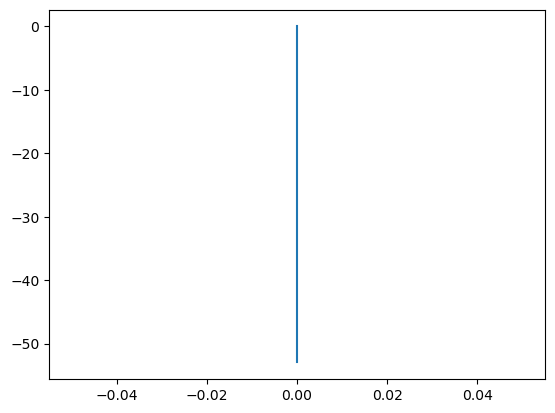

In [8]:
plt.plot(df.x, df.y)

## Use pygame to visualize the simulation in real time
The `pygame_test.py` file uses pygame to instantiate a Drone object (as defined in `drone.py`) and visualize it in real time. Right now the drone is the same as the ball defined above.

Open a terminal, make sure the proper environment is activated (`conda activate 2ddrone`), and run `python pygame_test.py`.

Note that the Drone class includes a method to draw the drone on a pygame surface.  Understand how the method works

In [9]:
# import pygame
# from drone import Drone

# # pygame setup
# pygame.init()
# screen = pygame.display.set_mode((1280, 720))
# clock = pygame.time.Clock()
# running = True
# dt = 0

# drone = Drone(0,0,1,2,1)

# while running:
#     # poll for events
#     # pygame.QUIT event means the user clicked X to close your window
#     for event in pygame.event.get():
#         if event.type == pygame.QUIT:
#             running = False
#         if event.type == pygame.KEYDOWN:
#             if event.key == pygame.K_q:
#                 running = False
#             if event.key == pygame.K_SPACE:
#                 # This code executes once every time the space key is pressed 
#                 pass
            

#     keys = pygame.key.get_pressed()
#     if keys[pygame.K_w]:
#         # This code will execute for every frame in which the given key is pressed
#         pass

#     # fill the screen with a color to wipe away anything from last frame
#     screen.fill("black")

#     drone.drawOnSurface(screen, 100)

#     # flip() the display to put your work on screen
#     pygame.display.flip()

#     # limits FPS to 60
#     # dt is delta time in seconds since last frame, used for framerate-
#     # independent physics.
#     dt = clock.tick(60) / 1000
    
#     drone.step(dt)
#     print(drone.y)

# pygame.quit()



### Exercise 1.4

Modify `drone.py` such that the Drone is drawn as an horizontal rectangle with a width of 50 cm and an height of 20 cm.  For now, we assume that the drone can not rotate and is always upright.

In [10]:
# import pygame
# from drone import Drone

# # pygame setup
# pygame.init()
# screen = pygame.display.set_mode((1280, 720))
# clock = pygame.time.Clock()
# running = True
# dt = 0

# drone = Drone(0,0,1,2,1)

# while running:
#     # poll for events
#     # pygame.QUIT event means the user clicked X to close your window
#     for event in pygame.event.get():
#         if event.type == pygame.QUIT:
#             running = False
#         if event.type == pygame.KEYDOWN:
#             if event.key == pygame.K_q:
#                 running = False
#             if event.key == pygame.K_SPACE:
#                 # This code executes once every time the space key is pressed 
#                 pass
            

#     keys = pygame.key.get_pressed()
#     if keys[pygame.K_w]:
#         # This code will execute for every frame in which the given key is pressed
#         pass

#     # fill the screen with a color to wipe away anything from last frame
#     screen.fill("black")

#     drone.drawOnSurface(screen, 100)

#     # flip() the display to put your work on screen
#     pygame.display.flip()

#     # limits FPS to 60
#     # dt is delta time in seconds since last frame, used for framerate-
#     # independent physics.
#     dt = clock.tick(60) / 1000
    
#     drone.step(dt)
#     print(drone.y)

# pygame.quit()



### Exercise 1.5

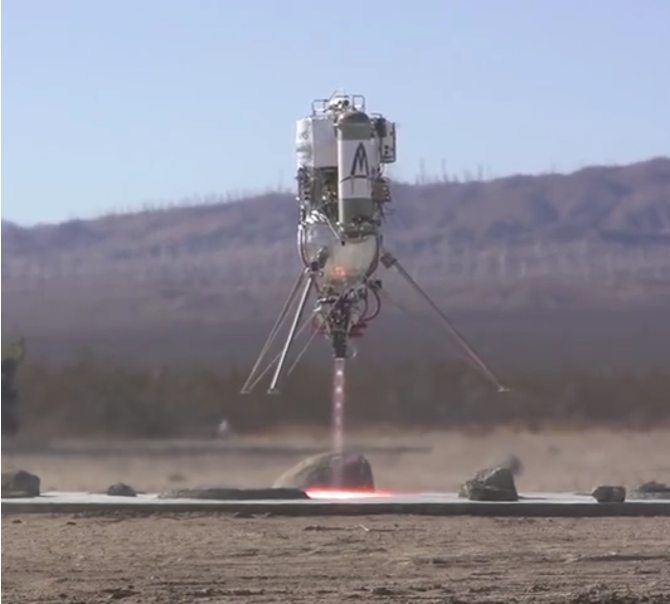

Masten Space Systems -- Xoie hovering rocket robot ([video](https://youtu.be/Rn6xIfY_3zM))


Let's modify our drone such that we add a *control variable*.  The drone has a single thruster on its bottom that can exert a maximum upwards force of 20 Newtons.

Change `drone.py` as follows:
- add a parameter to the constructor (i.e. the `__init__()` function) that represents the maximum thrust (which is a force, measured in Newtons) of the thruster.  Let's say default it to 20 N (which can lift approx 2 kg).  Save it to `self`, just like you did to the mass.
- add a parameter to the `Drone.step(self, dt)` that becomes `Drone.step(self, thrust, dt)` function that represents the thrust that the thruster is exerting in this timestep. Let's represent it as a number from 0 (no thrust) to 1 (maximum thrust).
- in the body of `step`, take this force into account when you compute the resultant force `fx` and `fy` (which are represented in Newtons)
- keep track of the last value of the thrust control variable by saving it to a variable `self.thrust`
- modify `pygame_test` such that when you press the `w` key, the thruster is fired at maximum power, otherwise it is not fired.
- run the simulation and see if it works

Experiment with the following:
- What happens to the horizontal component of the velocity of the drone that you are simulating? Do you have a way to change it when controlling the drone?

In [11]:
# import pygame
# from drone_thrust import Drone

# # pygame setup
# pygame.init()
# screen = pygame.display.set_mode((1280, 720))
# clock = pygame.time.Clock()
# running = True
# dt = 0
# thrust = 0
# max_thrust = 900
# drone = Drone(0,0,1,2,1, max_thrust=max_thrust)

# while running:
#     # poll for events
#     # pygame.QUIT event means the user clicked X to close your window
#     for event in pygame.event.get():
#         if event.type == pygame.QUIT:
#             running = False
#         if event.type == pygame.KEYDOWN:
#             if event.key == pygame.K_q:
#                 running = False
#             if event.key == pygame.K_SPACE:
#                 # This code executes once every time the space key is pressed 
#                 pass
                              

#     keys = pygame.key.get_pressed()
#     if keys[pygame.K_w]:
#         # This code will execute for every frame in which the given key is pressed
#         thrust = 1
#     else:
#         thrust = 0


#     # fill the screen with a color to wipe away anything from last frame
#     screen.fill("black")

#     drone.drawOnSurface(screen, 100)

#     # flip() the display to put your work on screen
#     pygame.display.flip()

#     # limits FPS to 60
#     # dt is delta time in seconds since last frame, used for framerate-
#     # independent physics.
#     dt = clock.tick(60) / 1000
    
#     drone.step(thrust, dt)
#     # print(drone.y)

# pygame.quit()



### Exercise 1.6

We would like to have visual feedback in our simulation of the amount of thrust. Modify `Drone.drawOnSurface` to draw a yellow triangle (or yellow line) pointing downwards from your drone (representing "fire"), with a length proportional to the thrust the drone is exerting. Look into the documentation of [pygame.draw](https://www.pygame.org/docs/ref/draw.html)

Try your simulation again.

In [12]:
#DONE

### Exercise 1.7

Modify `pygame_test` in such a way that every time you press SPACE (once per keypress) you instantiate a new drone at coordinates (0,0) moving 1m/s in a random direction.  Instead of a single drone, you'll have to keep track of a variable-length list of drones. You'll have to draw them all, and step them all in your main loop.

When you press the E key, remove all simulated drones.

In [13]:
# import pygame
# from drone_thrust import Drone
# import random 
# # pygame setup
# pygame.init()
# screen = pygame.display.set_mode((1280, 720))
# clock = pygame.time.Clock()
# running = True
# dt = 0
# thrust = 0
# max_thrust = 30
# drone_list = []


# while running:
#     # poll for events
#     # pygame.QUIT event means the user clicked X to close your window
#     for event in pygame.event.get():
#         if event.type == pygame.QUIT:
#             running = False
#         if event.type == pygame.KEYDOWN:
#             if event.key == pygame.K_q:
#                 running = False
#             if event.key == pygame.K_SPACE:
#                 # This code executes once every time the space key is pressed 
#                 drone = Drone(x=0,y=0,vx=random.randint(-1,1),vy=random.randint(-1,1),theta=0,omega=0,max_thrust=max_thrust)
#                 drone_list.append(drone)

#             if event.key == pygame.K_e:
#                 drone_list = []
                
                              
#     keys = pygame.key.get_pressed()
#     if keys[pygame.K_w]:
#         # This code will execute for every frame in which the given key is pressed
#         thrust = 1
#     else:
#         thrust = 0


#     # fill the screen with a color to wipe away anything from last frame
#     screen.fill("black")
#     for d in drone_list:
#         d.drawOnSurface(screen, 100)

#     # flip() the display to put your work on screen
#     pygame.display.flip()

#     # limits FPS to 60
#     # dt is delta time in seconds since last frame, used for framerate-
#     # independent physics.
#     dt = clock.tick(60) / 1000
#     if drone_list:
#         for d in drone_list:
#             d.step(thrust, dt)
#     # print(drone.y)

# pygame.quit()



### Exercise 1.8

Let's now handle the rotation of the drone in the 2D plane.

We'll need two new state variables:
- The drone angle `theta`.  It is an angle, in radians, such that 0 means that the drone is upright, 1 means that it is rotated 1 radians counterclockwise, pi/2 means that it is rotated 90 degrees to the left, etc.
- The drone angular velocity `omega`.  It is an angular velocity, in radians per second, such that 0 means that the drone is not rotating (but it could be not upright), 1 means that it is rotating 1 radians per second counterclockwise, etc.

Add these state variables to your `Drone` class, both in the constructor and in `step`. Note that in `step` you will need to update `theta` at each frame according to `omega`, but you currently have no way to update `omega`, which will not change during the simulation.  It is OK.

Now, modify the Drone class such that you draw your drone according to its rotation. The easiest way is to draw the drone as a circle with a given radius (say, 0.5 m), centered on its position, with a small line moving from the center of the drone to the top of the drone to indicate its direction.  You can draw the thrust as a line exiting from the opposite "side" of the drone.

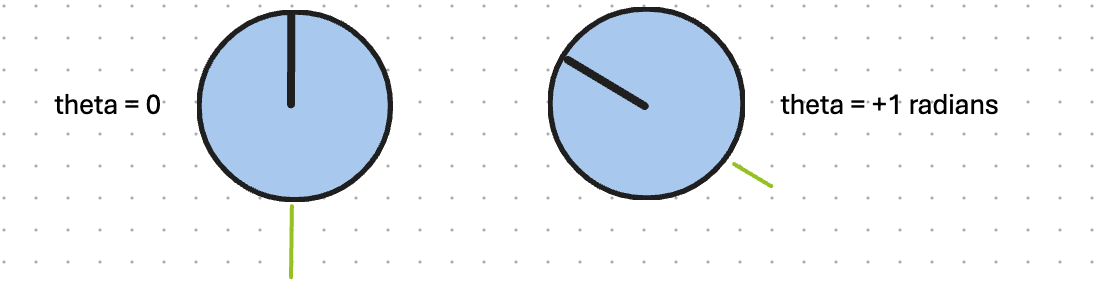

You can use the following functions of pygame.draw:
- [circle](https://www.pygame.org/docs/ref/draw.html#pygame.draw.circle)
- [line](https://www.pygame.org/docs/ref/draw.html#pygame.draw.line)

For example, if my drone is at x,y and oriented as theta, with a radius of r, the "up" line should be drawn between points:
- $x$, $y$
- $x - r \cdot \sin(\theta)$, $y + r \cdot \cos(\theta)$

Test your drawing functions by running your simulation as follows:
- Create a drone with `omega = 0`.  It should not rotate
- Create a drone with `omega = +1`.  It should rotate at approximately 60 degrees per second.

Now, make sure that your step function is correctly simulating the physics of the thurster. Consider that, now that the drone has a rotation of `theta`, the thruster will exert a force both towards y and towards x. In particular, if $f$ is the total force of the thruster, we expect:
- fx = $- f \cdot \sin(\theta)$
- fy = $f \cdot \cos(\theta)$

Test your simulation with a drone rotating with `omega` = 3 rad/s.
Can you control it to keep hovering by just firing it in the correct moments?  What if you increase the maximum force of the thruster to 100 N?

In [16]:
import pygame
from drone_thrust_polygon import Drone
import random 
# pygame setup
pygame.init()
screen = pygame.display.set_mode((1280, 720))
clock = pygame.time.Clock()
running = True
dt = 0
thrust = 0
max_thrust = 30
drone_list = []


while running:
    # poll for events
    # pygame.QUIT event means the user clicked X to close your window
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False
        if event.type == pygame.KEYDOWN:
            if event.key == pygame.K_q:
                running = False
            if event.key == pygame.K_SPACE:
                # This code executes once every time the space key is pressed 
                drone = Drone(x=0,y=0,vx=random.randint(-1,1),vy=random.randint(-1,1),theta=0,omega=0.5,max_thrust=max_thrust)
                drone_list.append(drone)

            if event.key == pygame.K_e:
                drone_list = []
                
                              
    keys = pygame.key.get_pressed()
    if keys[pygame.K_w]:
        # This code will execute for every frame in which the given key is pressed
        thrust = 1
    else:
        thrust = 0


    # fill the screen with a color to wipe away anything from last frame
    screen.fill("black")
    for d in drone_list:
        d.drawOnSurface(screen, 100)

    # flip() the display to put your work on screen
    pygame.display.flip()

    # limits FPS to 60
    # dt is delta time in seconds since last frame, used for framerate-
    # independent physics.
    dt = clock.tick(60) / 1000
    if drone_list:
        for d in drone_list:
            d.step(thrust, dt)
    # print(drone.y)

pygame.quit()

